# HYDRO30 Surface Water Extent Map from Sentinel-1 SAR

Create water masks from NRB data in an DEA's Open Data Cube (ODC), accessed via STAC. Using the ASF's HydroSAR algorithm

<img style= "padding: 7px" src="https://courses.edx.org/asset-v1:AlaskaX+SAR-401+3T2020+type@asset+block@Watermappingworkflow2.jpg" width="60%"/>


## Import libraries

Need to install the branch of HydroSAR that is set up for odc-stac.

the `hydrosar.water_map.make_water_map` function has been edited to return xarray datasets, in addition to writing results to geotiff. Provided in the `water_map.py` file on this repo

In [1]:
# !git clone --depth 1 --branch feature/odc_data_access https://github.com/HydroSAR/HydroSAR.git
# !python -m pip install -e HydroSAR 

In [2]:
from odc.stac import load
from odc.geo import BoundingBox
from pystac_client import Client
from odc.stac import configure_s3_access

import numpy as np
import xarray as xr
import rioxarray as rxr
import contextily as ctx
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from tqdm.auto import tqdm
from pathlib import Path

# from hydrosar.water_map import make_water_map
from water_map import make_water_map

## Analysis Parameters

In [3]:
central_lat, central_lon = -35.2944, 149.1149
buffer = 0.04

aus_start_date = "2025-01-01"
aus_end_date = "2025-06-30"



The example below accesses a small stack of NRB data from Digital Earth Australia's (DEA's) ODC

**Open a STAC client to the catalog and configure anonymous access to AWS S3**

In [4]:
catalog = "https://explorer.dev.dea.ga.gov.au/stac"

stac_client = Client.open(catalog)

configure_s3_access(
    cloud_defaults=True, 
    aws_unsigned=True,
)

View the region we're loading

In [5]:
aus_bbox = BoundingBox(
    left=central_lon - buffer,
    bottom=central_lat - buffer,
    right=central_lon + buffer,
    top=central_lat + buffer,
    crs="EPSG:4326"
)

aus_bbox.explore()

## Query the STAC catalog

In [6]:
collections_query = ["ga_s1_nrb_iw_vv_vh_0"]
aus_date_query = f"{aus_start_date}/{aus_end_date}"
aus_bbox_query = aus_bbox.bbox

aus_items = stac_client.search(
    collections=collections_query,
    datetime=aus_date_query,
    bbox=aus_bbox_query
).item_collection()

print(f"Found {len(aus_items)} items")

Found 112 items


## Load the data into an `xarray.Dataset`

In [7]:
# Lazy load our filtered data
ds = load(
    aus_items,
    crs="EPSG:3577",
    resolution=20,
    intersects=aus_bbox.boundary(),
    bands=["VV_gamma0", "VH_gamma0", "mask"],
    groupby="solar_day",
    chunks={},
)

ds = ds.rename({'VV_gamma0': 'VV', 'VH_gamma0': 'VH'})

## Resample


In [8]:
ds = ds.resample(time='MS').mean().compute()
ds

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.Dataset> Size: 15MB
Dimensions:      (time: 6, y: 490, x: 420)
Coordinates:
  * y            (y) float64 4kB -3.954e+06 -3.954e+06 ... -3.964e+06 -3.964e+06
  * x            (x) float64 3kB 1.545e+06 1.545e+06 ... 1.553e+06 1.553e+06
    spatial_ref  int32 4B 3577
  * time         (time) datetime64[ns] 48B 2025-01-01 2025-02-01 ... 2025-06-01
Data variables:
    VV           (time, y, x) float32 5MB 0.2226 1.604 0.7821 ... 0.5352 0.4003
    VH           (time, y, x) float32 5MB 0.0364 0.03746 ... 0.1123 0.07445
    mask         (time, y, x) float32 5MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

## Create water masks using HydroSAR

Results will also be exported as COG's into the folder 'water_masks'

In [9]:
water_mask_dir = Path.cwd() / "water_masks"
water_mask_dir.mkdir(exist_ok=True)

arrs=[]
for dt in tqdm(ds.time):
    vv = ds["VV"].sel(time=dt)
    vh = ds["VH"].sel(time=dt)

    date = "".join(str(dt.values.astype("datetime64[D]")).split("-"))
    water_extent_output = water_mask_dir / f'water_extent_{date}.tif'

    wm = make_water_map(
            water_extent_output, 
            vv, 
            vh, 
            # tile_shape=(100, 100),
            # max_vv_threshold=-30, 
            # max_vh_threshold=-24., 
            # hand_threshold=15., 
            # hand_fraction=0.8
        )
    
    # add back time dim
    wm = wm.expand_dims(time=[dt.values])
    arrs.append(wm)

#combine timesteps back together
water_extent = xr.concat(arrs, dim='time')

  0%|          | 0/6 [00:00<?, ?it/s]

Threshold too high! Using maximum threshold -23.0 db
Threshold too high! Using maximum threshold -23.0 db
Threshold too high! Using maximum threshold -15.5 db


## Plot the results

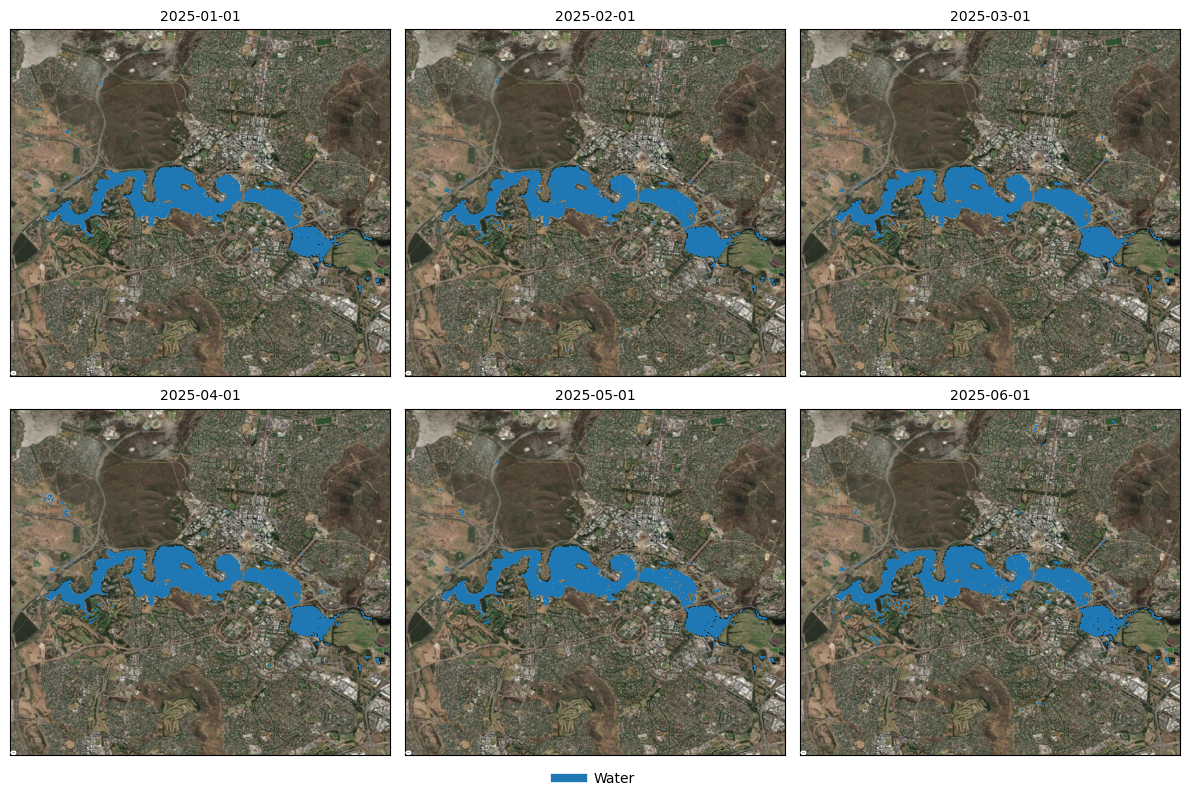

In [10]:
# Make a custom colormap: 0 = transparent, 1 = blue
cmap = ListedColormap(["none", "#1f78b4"]) 

# Setup figure panels
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, ax in enumerate(axes.ravel()):
    if i < water_extent.sizes['time']:
        da = water_extent.isel(time=i)

        #to web mercartor
        da = da.odc.reproject(how=da.odc.geobox.to_crs('EPSG:3857'))

        # Plot binary water extent
        im = da.plot(
            ax=ax,
            cmap=cmap,
            add_colorbar=False,
        )

        ctx.add_basemap(ax,
                source=ctx.providers.Esri.WorldImagery,
                attribution='ESRI',
                attribution_size=1)  # nice terrain map)

        # Remove ticks and labels
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')

        # Add date as title
        ax.set_title(str(np.datetime_as_string(da['time'].values, unit='D')), fontsize=10)

    else:
        ax.axis('off')

# Add legend
fig.legend(
    handles=[plt.Line2D([0], [0], color="#1f78b4", lw=6, label="Water")],
    loc='lower center',
    ncol=1,
    frameon=False,
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.05);
